# CO2 Emissions Forecasting with XGBoost
This notebook trains a simple XGBoost model to forecast CO2 emissions for the next 10 years (120 months) based on historical data.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

### 1. Load and Preprocess Data

In [18]:
# Load dataset
df = pd.read_csv("data.csv")

# Filter for Total Energy Electric Power Sector
df = df[df["Description"] == "Total Energy Electric Power Sector CO2 Emissions"].copy()

# Convert YYYYMM to datetime and set as index
df["Date"] = pd.to_datetime(df["YYYYMM"], format="%Y%m", errors="coerce")
df = df.set_index("Date")
df = df.sort_index()

# Convert Value to numeric, forcing non-numeric to NaN
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Value"])

# Keep only the target variable
ts = df[["Value"]].copy()
ts.columns = ["CO2"]

ts.head()

,CO2
Date,
1973-01-01,111.621
1973-02-01,99.185
1973-03-01,99.112
1973-04-01,93.183
1973-05-01,98.012


### 2. Feature Engineering
We will create lag features (previous month, same month last year) to capture autoregressive properties and yearly seasonality.

In [19]:
# Create lag features
ts["lag_1"] = ts["CO2"].shift(1)
ts["lag_12"] = ts["CO2"].shift(12)
ts["month"] = ts.index.month

# Drop NaN values created by shifting
ts = ts.dropna()

X = ts[["lag_1", "lag_12", "month"]]
y = ts["CO2"]

X.head()

,lag_1,lag_12,month
Date,,,
1974-01-01,105.089,111.621,1.0
1974-02-01,105.530,99.185,2.0
1974-03-01,93.928,99.112,3.0
1974-04-01,97.857,93.183,4.0
1974-05-01,92.293,98.012,5.0


### 3. Train XGBoost Model

In [20]:
X.dtypes

lag_1     float64
lag_12    float64
month     float64
dtype: object

In [21]:
# Initialize and fit the XGBoost Regressor
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective="reg:squarederror")
model.fit(X, y)
print("Model training complete.")

Model training complete.


### 4. Forecast Next 10 Years
We predict step-by-step for the next 120 months.

In [22]:
# 10 years = 120 months
forecast_periods = 120
future_dates = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=forecast_periods, freq="MS")

future_predictions = []
history = ts["CO2"].tolist()

for date in future_dates:
    # Extract features from history
    lag_1 = history[-1]
    lag_12 = history[-12]
    month = date.month
    
    # Create dataframe for the single prediction step
    X_pred = pd.DataFrame([[lag_1, lag_12, month]], columns=["lag_1", "lag_12", "month"])
    
    # Predict
    pred = model.predict(X_pred)[0]
    
    # Append to predictions and history for next iterations
    future_predictions.append(pred)
    history.append(pred)

future_df = pd.DataFrame({"Date": future_dates, "Predicted_CO2": future_predictions}).set_index("Date")
future_df.head()

,Predicted_CO2
Date,
2016-08-01,196.735168
2016-09-01,177.952820
2016-10-01,150.739044
2016-11-01,136.307434
2016-12-01,146.330688


### 5. Plot the Results

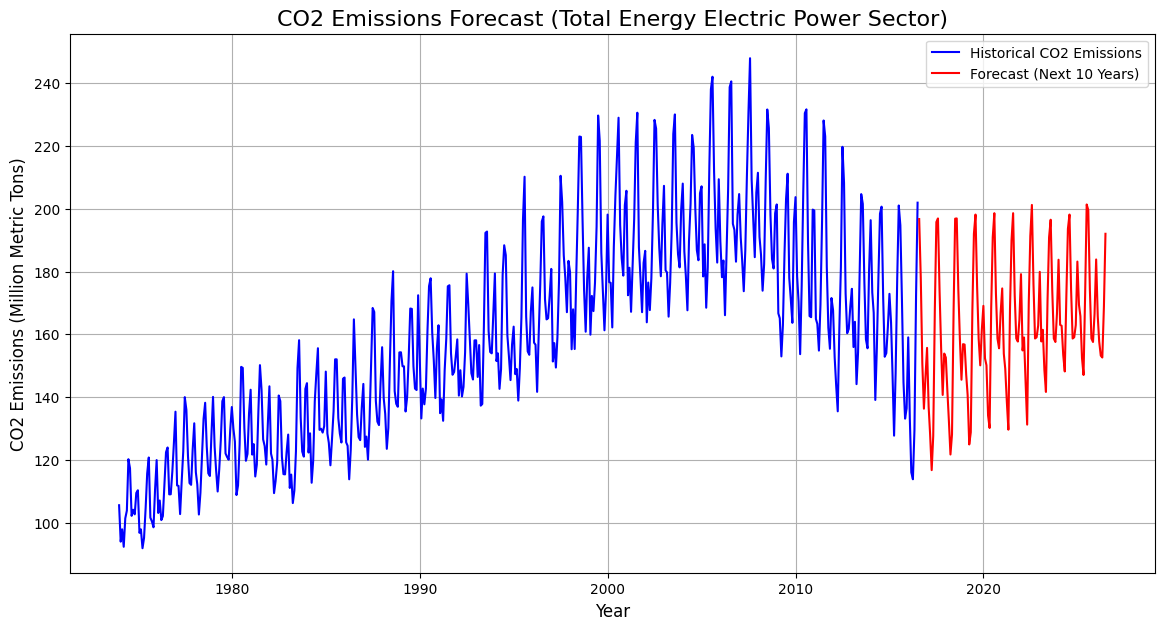

In [23]:
plt.figure(figsize=(14, 7))
plt.plot(ts.index, ts["CO2"], label="Historical CO2 Emissions", color="blue")
plt.plot(future_df.index, future_df["Predicted_CO2"], label="Forecast (Next 10 Years)", color="red")

plt.title("CO2 Emissions Forecast (Total Energy Electric Power Sector)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO2 Emissions (Million Metric Tons)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()